In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from chemevo import evolution as evo

params = {
   'axes.labelsize': 15,
   'font.size': 15,
   'legend.fontsize': 10,
   'xtick.minor.visible': True,
   'ytick.minor.visible': True,
   'xtick.labelsize': 15,
   'ytick.labelsize': 15,
   'text.usetex': False, #to use TeX in your labels
   'font.family':'serif',
   'axes.titlesize': 15,
   'xtick.direction': 'in',
   'ytick.direction': 'in',
   'xtick.top': True,
   'ytick.right': True,
   'xtick.major.size': 6,
   'xtick.minor.size': 3,
   'ytick.major.size': 6,
   'ytick.minor.size': 3
   }
rcParams.update(params)

colors = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#F0E442"]

# Numerical Integration, with constant and exponential SFRs

Numerical integrations:

In [6]:
t_array = np.linspace(0,14,int(1e3))
m_g_array_const = np.ones(len(t_array))
model1 = evo.Galaxy(t_array, m_g_array=m_g_array_const)
Z_oxygen_const = model1.compute_z_O()
Z_Iron_const = model1.compute_z_Fe()

tau_sfh = 6 #Gyrs
m_g_array_exp = 1 * np.exp(-t_array/tau_sfh)
model2 = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_exp)

Z_oxygen_exp = model2.compute_z_O()
Z_Iron_exp = model2.compute_z_Fe()

Analytical solutions to compare:

In [7]:
Z_O_eq_const_sfr = model1.analytic_eq_O("constant")
Z_O_const_sfr_ana = model1.analytic_solutions_O("constant")

Z_O_eq_exp_sfr = model2.analytic_eq_O("exponential")
Z_O_exp_sfr_ana = model2.analytic_solutions_O("exponential")

In [8]:
Z_Fe_eq_const_sfr = model1.analytic_eq_Fe("constant")
Z_Fe_const_sfr_ana = model1.analytic_solutions_Fe("constant", 'sum')

Z_Fe_eq_exp_sfr = model2.analytic_eq_Fe("exponential")
Z_Fe_exp_sfr_ana = model2.analytic_solutions_Fe("exponential", 'sum')

# Oxygen abundance 

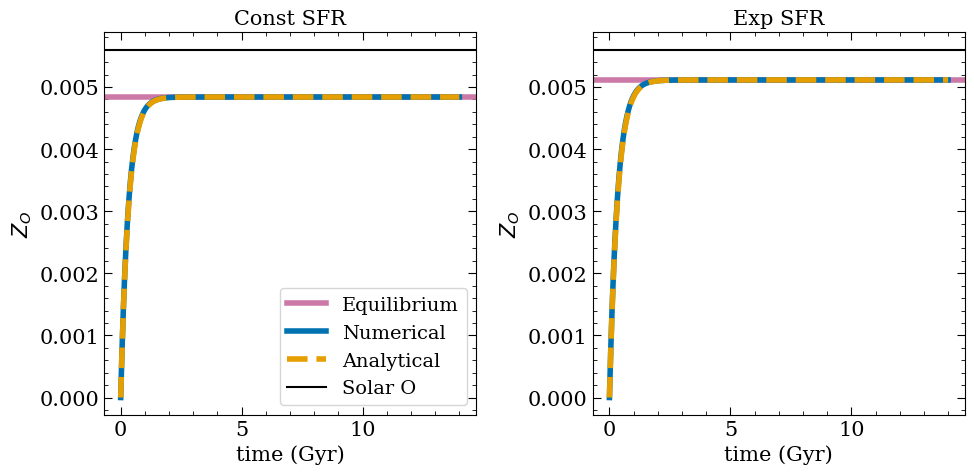

In [21]:
plt.figure(figsize=(10,5))

plt.subplot(1, 2, 1)
plt.axhline(Z_O_eq_const_sfr, color = colors[4], label = 'Equilibrium', lw = 4)
plt.plot(t_array, Z_oxygen_const, color = colors[0], lw = 4, label = 'Numerical')
plt.plot(t_array, Z_O_const_sfr_ana, color = colors[1], alpha = 1, label = 'Analytical', lw = 4, linestyle = '--')
plt.axhline(model1.SolarO, color = 'black', label = 'Solar O')

plt.xlabel('time (Gyr)')
plt.ylabel(r'$Z_{O}$')
plt.title("Const SFR")
plt.legend(fontsize=14)
plt.tight_layout()



plt.subplot(1, 2, 2)
plt.axhline(Z_O_eq_exp_sfr, lw = 4, color = colors[4])
plt.plot(t_array, Z_oxygen_exp, color = colors[0], lw = 4)
plt.plot(t_array, Z_O_exp_sfr_ana, color = colors[1], lw = 4, linestyle = '--')
plt.axhline(model1.SolarO, color = 'black', label = 'Solar O')


plt.xlabel('time (Gyr)')
plt.ylabel(r'$Z_{O}$')
plt.title("Exp SFR")
plt.tight_layout()

# Iron abundance

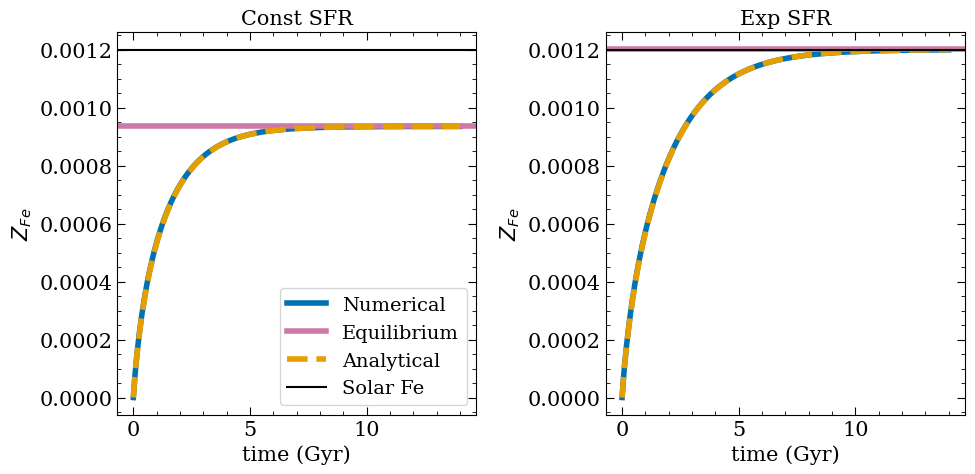

In [20]:
plt.figure(figsize=(10,5))

plt.subplot(1, 2, 1)
plt.plot(t_array, Z_Iron_const, color = colors[0], alpha = 1, lw = 4, label = 'Numerical')
plt.axhline(Z_Fe_eq_const_sfr, color = colors[4], label = 'Equilibrium', lw = 4)
plt.plot(t_array, Z_Fe_const_sfr_ana, color = colors[1], alpha = 1, label = 'Analytical', lw = 4, linestyle = '--')
plt.axhline(model1.SolarFe, color = 'black', label = 'Solar Fe')

plt.legend(fontsize = 14)
plt.xlabel('time (Gyr)')
plt.ylabel(r'$Z_{Fe}$')
plt.title("Const SFR")
plt.tight_layout()



plt.subplot(1, 2, 2)
plt.plot(t_array, Z_Iron_exp, color = colors[0], lw = 4)
plt.plot(t_array, Z_Fe_exp_sfr_ana, color = colors[1], lw = 4, linestyle = '--')
plt.axhline(Z_Fe_eq_exp_sfr[0], color = colors[4], lw = 4)
plt.axhline(model1.SolarFe, color = 'black', label = 'Solar Fe')

plt.xlabel('time (Gyr)')
plt.ylabel(r'$Z_{Fe}$')
plt.title("Exp SFR")
plt.tight_layout()

# Everything in [X/Y] 

In [11]:
SolarO=0.0056		# solar oxygen abundance by mass
SolarFe=0.0012		# solar iron abundance by mass

def ratio_to_sun(star, sun):
    return np.log10(star/sun + 1e-10)

#for constant SFR
consts = pd.DataFrame(columns=['O_H', 'Fe_H', 'O_Fe'])

consts['O_H'] = ratio_to_sun(Z_oxygen_const, SolarO)
consts['Fe_H'] = ratio_to_sun(Z_Iron_const, SolarFe)
consts = consts[(consts['O_H'] > -10) & (consts['Fe_H'] > -10)]
consts['O_Fe'] = consts['O_H'] - consts['Fe_H']

#For exp SFRs
exps = pd.DataFrame(columns=['O_H', 'Fe_H', 'O_Fe'])
exps['O_H'] = ratio_to_sun(Z_oxygen_exp, SolarO)
exps['Fe_H'] = ratio_to_sun(Z_Iron_exp, SolarFe)
exps = exps[(exps['O_H'] > -10) & (exps['Fe_H'] > -10)]
exps['O_Fe'] = exps['O_H'] - exps['Fe_H']

Text(0, 0.5, '[O/Fe]')

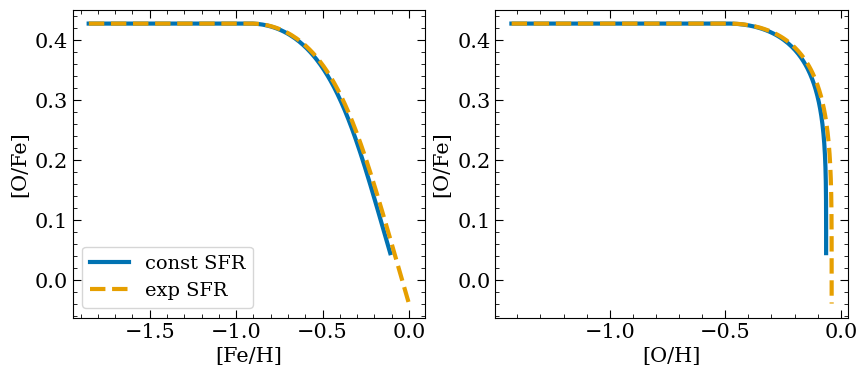

In [12]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(consts['Fe_H'], consts['O_Fe'], lw = 3, color = colors[0], label = 'const SFR')
plt.plot(exps['Fe_H'], exps['O_Fe'], lw = 3, linestyle = '--', color = colors[1], label = 'exp SFR')
plt.xlabel('[Fe/H]')
plt.ylabel('[O/Fe]')
plt.legend(fontsize=14)

plt.subplot(1,2,2)
plt.plot(consts['O_H'], consts['O_Fe'], lw = 3, color = colors[0], label = 'const SFR')
plt.plot(exps['O_H'], exps['O_Fe'], lw = 3, linestyle = '--', color = colors[1], label = 'exp SFR')
plt.xlabel('[O/H]')
plt.ylabel('[O/Fe]')

# More eta and tau*

In [13]:
etas = [2.5, 5, 1, 2.5]
tau_stars = [1, 1, 1, 3]

oxys_list_const = []
irons_list_const = []

oxys_list_exp = []
irons_list_exp = []

#Const SFR
for i in range(len(etas)):
    model_i = evo.Galaxy(t_array, m_g_array=m_g_array_const, eta=etas[i], tau_star=tau_stars[i])
    oxys_list_const.append(model_i.compute_z_O())
    irons_list_const.append(model_i.compute_z_Fe())

In [14]:
#Exp SFR
for i in range(len(etas)):
    model_i = evo.Galaxy(t_array, m_g_array=m_g_array_exp, eta=etas[i], tau_star=tau_stars[i])
    oxys_list_exp.append(model_i.compute_z_O())
    irons_list_exp.append(model_i.compute_z_Fe())

Text(0, 0.5, '[O/Fe]')

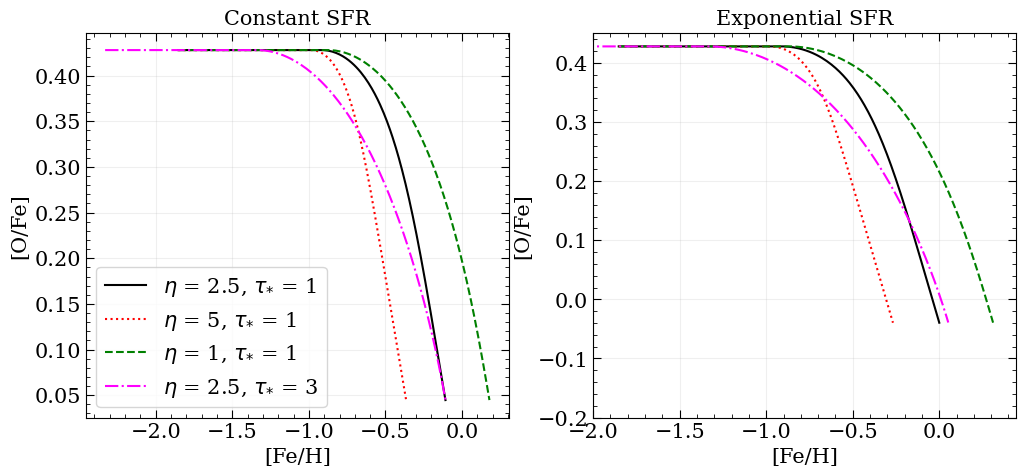

In [15]:
color_map = ['black', 'red', 'green', 'magenta']
line = ['-', ':', '--', '-.']

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
for i in range(len(oxys_list_const)):
    O_H_temp = ratio_to_sun(oxys_list_const[i], SolarO)
    O_H_temp = O_H_temp[np.where(O_H_temp > -10)]
    Fe_H_temp = ratio_to_sun(irons_list_const[i], SolarFe)
    Fe_H_temp = Fe_H_temp[np.where(Fe_H_temp > -10)]
    O_Fe_temp = O_H_temp - Fe_H_temp
    plt.plot(Fe_H_temp, O_Fe_temp, label = r'$\eta$ = ' + f"{etas[i]}" + r', $\tau_{*}$ = ' + f"{tau_stars[i]}", color = color_map[i], linestyle = line[i])

plt.grid('True', alpha = 0.2)
plt.legend(fontsize = 15)
plt.title("Constant SFR")
plt.xlabel('[Fe/H]')
plt.ylabel('[O/Fe]')


plt.subplot(1,2,2)
for i in range(len(oxys_list_exp)):
    O_H_temp = ratio_to_sun(oxys_list_exp[i], SolarO)
    O_H_temp = O_H_temp[np.where(O_H_temp > -10)]
    Fe_H_temp = ratio_to_sun(irons_list_exp[i], SolarFe)
    Fe_H_temp = Fe_H_temp[np.where(Fe_H_temp > -10)]
    O_Fe_temp = O_H_temp - Fe_H_temp
    plt.plot(Fe_H_temp, O_Fe_temp, label = r'$\eta$ = ' + f"{etas[i]}" + r', $\tau_{*}$ = ' + f"{tau_stars[i]}", color = color_map[i], linestyle = line[i])

plt.xlim(-2,)
plt.ylim(-0.2,)
plt.grid('True', alpha = 0.2)
plt.title("Exponential SFR")
plt.xlabel('[Fe/H]')
plt.ylabel('[O/Fe]')

Text(0, 0.5, '[O/Fe]')

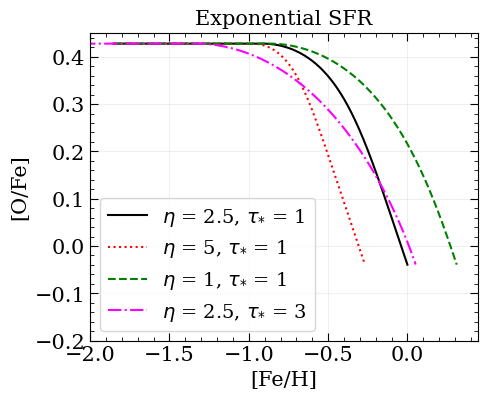

In [16]:
color_map = ['black', 'red', 'green', 'magenta']
line = ['-', ':', '--', '-.']

plt.figure(figsize=(5,4))


for i in range(len(oxys_list_exp)):
    O_H_temp = ratio_to_sun(oxys_list_exp[i], SolarO)
    O_H_temp = O_H_temp[np.where(O_H_temp > -10)]
    Fe_H_temp = ratio_to_sun(irons_list_exp[i], SolarFe)
    Fe_H_temp = Fe_H_temp[np.where(Fe_H_temp > -10)]
    O_Fe_temp = O_H_temp - Fe_H_temp
    plt.plot(Fe_H_temp, O_Fe_temp, label = r'$\eta$ = ' + f"{etas[i]}" + r', $\tau_{*}$ = ' + f"{tau_stars[i]}", color = color_map[i], linestyle = line[i])

plt.legend(fontsize=14)
plt.xlim(-2,)
plt.ylim(-0.2,)
plt.grid('True', alpha = 0.2)
plt.title("Exponential SFR")
plt.xlabel('[Fe/H]')
plt.ylabel('[O/Fe]')